In [1]:
import pandas as pd
import os

# 데이터를 읽어봅시다.
train_data = pd.read_table(os.getenv("HOME") + '/data/ratings_train.txt')
test_data = pd.read_table(os.getenv("HOME") + '/data/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


실습 때 다루었던 IMDB 데이터셋은 텍스트를 가공하여 imdb.data_loader() 메서드를 호출하면 숫자 인덱스로 변환된 텍스트와 word_to_index 딕셔너리까지 친절하게 제공합니다. 그러나 이번에 다루게 될 nsmc 데이터셋은 전혀 가공되지 않은 텍스트 파일로 이루어져 있습니다. 이것을 읽어서 imdb.data_loader()와 동일하게 동작하는 자신만의 data_loader를 만들어 보는 것으로 시작합니다. data_loader 안에서는 다음을 수행해야 합니다.  

데이터의 중복 제거  
NaN 결측치 제거  
한국어 토크나이저로 토큰화  
불용어(Stopwords) 제거  
사전word_to_index 구성  
텍스트 스트링을 사전 인덱스 스트링으로 변환  
X_train, y_train, X_test, y_test, word_to_index 리턴

In [2]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)
index_to_word = {index:word for word, index in word_to_index.items()}

In [3]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

3) 모델 구성을 위한 데이터 분석 및 가공  
전체 문장의 평균 길이 +- 3표준편차까지 반영하여 97%를 포함할수 있는 최대 길이인 55글자를 택했고,  
torch.nn.utils.rnn.pad_sequence 을 활용하여 패딩을 추가하였다. 이때 pad_sequence는 현재 리스트 안에서 가장 긴 길이에 맞춰 paddin하므로 max_len으로 잘랐더라도 실제 가장 긴 문장이 max_len보다 짧으면 shape가 max_len보다 작을 수 있으니 max_len으로 맞춰지도록 문장의 뒤에(padding은 뒤에 적용하는것이 효율적임을 노드에서 배웠으니) 추가 padding함 

In [4]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab(dicpath='/usr/local/lib/mecab/dic/mecab-ko-dic')
stopwords = ['의','가','이','은','들','는','과','도','를','으로','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data = train_data.drop_duplicates(subset=['document'])
    train_data = train_data.dropna(how='any')
    test_data = test_data.drop_duplicates(subset=['document'])
    test_data = test_data.dropna(how='any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence)
        temp_X = [word for word in temp_X if word not in stopwords]
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence)
        temp_X = [word for word in temp_X if word not in stopwords]
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(num_words - 4)

    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]
    word_to_index = {word: index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index['<BOS>']] + [
            word_to_index[word] if word in word_to_index else word_to_index['<UNK>']
            for word in wordlist
        ]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return (
        X_train,
        np.array(train_data['label']),
        X_test,
        np.array(test_data['label']),
        word_to_index
    )

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data, num_words=10000)
index_to_word = {index: word for word, index in word_to_index.items()}

print(len(X_train), len(y_train))
print(len(X_test), len(y_test))
print(word_to_index['<PAD>'], word_to_index['<BOS>'], word_to_index['<UNK>'])

146182 146182
49157 49157
0 1 2


In [5]:
import numpy as np
import matplotlib.pyplot as plt

total_data_text = list(X_train) + list(X_test)

num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)

print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))

max_tokens = np.mean(num_tokens) + 3 * np.std(num_tokens)
maxlen = int(max_tokens)

print('pad_sequences maxlen : ', maxlen)

coverage = np.sum(num_tokens <= maxlen) / len(num_tokens)
print(f'전체 문장의 {coverage * 100:.2f}%가 maxlen 설정값 이내에 포함됩니다.')

문장길이 평균 :  17.064411100701857
문장길이 최대 :  117
문장길이 표준편차 :  12.912884807510581
pad_sequences maxlen :  55
전체 문장의 97.13%가 maxlen 설정값 이내에 포함됩니다.


In [6]:
for max_len in [20, 30, 40, 50, 60, 80, 100]:
    ratio = np.mean( num_tokens <= max_len)
    print(f"max_len={max_len:3d} | 포함 비율: {ratio * 100:.2f}%")

max_len= 20 | 포함 비율: 75.38%
max_len= 30 | 포함 비율: 87.77%
max_len= 40 | 포함 비율: 92.61%
max_len= 50 | 포함 비율: 95.68%
max_len= 60 | 포함 비율: 98.52%
max_len= 80 | 포함 비율: 99.99%
max_len=100 | 포함 비율: 100.00%


In [7]:
import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

PAD_IDX = word_to_index['<PAD>']

def pad_sequences_with_maxlen(sequences, max_len, padding_value=PAD_IDX):
    # 1. max_len보다 긴 문장은 자르기
    truncated = [seq[:max_len] for seq in sequences]

    # 2. tensor list로 변환
    tensor_list = [torch.tensor(seq, dtype=torch.long) for seq in truncated]

    # 3. 현재 배치 내 최대 길이에 맞춰 padding
    padded = pad_sequence(
        tensor_list,
        batch_first=True,
        padding_value=padding_value
    )

    # 4. 혹시 길이가 max_len보다 짧으면 오른쪽에 추가 padding
    if padded.size(1) < max_len:
        pad_size = max_len - padded.size(1)
        padded = F.pad(padded, (0, pad_size), value=padding_value)

    # 5. 혹시라도 max_len보다 길면 자르기
    padded = padded[:, :max_len]

    return padded

X_train_padded = pad_sequences_with_maxlen(X_train, maxlen)
X_test_padded = pad_sequences_with_maxlen(X_test, maxlen)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train_padded:", X_train_padded.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_padded:", X_test_padded.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_padded: torch.Size([146182, 55])
y_train_tensor: torch.Size([146182])
X_test_padded: torch.Size([49157, 55])
y_test_tensor: torch.Size([49157])


In [8]:
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(
        index_to_word.get(int(index), '<UNK>')
        for index in encoded_sentence
        if int(index) != word_to_index['<PAD>']
    )

print("원본 인덱스:", X_train_padded[0])
print("복원 문장:", get_decoded_sentence(X_train_padded[0], index_to_word))
print("라벨:", y_train_tensor[0].item())

원본 인덱스: tensor([  1,  32,  75, 943,   4,   4,  39, 232,  20,  33, 751,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0])
복원 문장: <BOS> 아 더 빙 . . 진짜 짜증 나 네요 목소리
라벨: 0.0


4) 모델 구성 및 validation set 구성  
모델은 3가지 이상 다양하게 구성하여 실험해 보세요.

---  
### 모델 구성  

1. LSTM  
    > Embedding dim = 100  
    > hidden state size = 64  
    > \+ dropout 적용 (이전 노드 예제에서 epoch=15 근처에서 빠르게 과적합되는 경향 관찰)  
    > BCEWithLogitsLoss   

2. Double Layer LSTM
    > 더 복잡한 표현을 학습할수 있도록 첫번째 LSTM에서 hidden state sequence를 출력하고 이 sequence를 토대로 기존 LSTM의 방식을 적용하는 방식 
    > CNN에서 여러 층을 쌓으면 receptive field가 넓어져 더 추상적인 표현을 학습할수 있게 된 것과 비슷한 느낌?  

3. 1D-CNN
    > kernel_size = 3, 5, 7 병렬 구성 -> 각 kernel 출력에 global maxpool하여 강한 특징을 추출하고 concat하여 분류  
    > \+ dropout  




In [9]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [10]:
# 공통 하이퍼파라미터 
vocab_size = len(word_to_index)
word_vector_dim = 100
hidden_size = 64
dropout_rate = 0.5
weight_decay = 1e-4
patience = 3
padding_idx = word_to_index['<PAD>']

print("vocab_size:", vocab_size)
print("padding_idx:", padding_idx)

vocab_size: 10000
padding_idx: 0


In [11]:
# 1. LSTM 
class LSTMSentimentModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, hidden_size=64, padding_idx=0, dropout=0.3):
        super().__init__()

        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=padding_idx
        )

        self.lstm = nn.LSTM(
            input_size=word_vector_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # x: [batch_size, seq_len]

        lengths = (x != self.padding_idx).sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)

        # 각 문장의 마지막 실제 토큰 위치
        last_indices = lengths - 1
        batch_indices = torch.arange(x.size(0), device=x.device)

        x = lstm_out[batch_indices, last_indices]

        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [12]:
class DoubleLayerLSTMSentimentModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, hidden_size=64, padding_idx=0, dropout=0.3):
        super().__init__()

        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=padding_idx
        )

        self.lstm = nn.LSTM(
            input_size=word_vector_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        lengths = (x != self.padding_idx).sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)

        last_indices = lengths - 1
        batch_indices = torch.arange(x.size(0), device=x.device)

        x = lstm_out[batch_indices, last_indices]

        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [13]:
class MultiKernelCNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, num_filters=64, padding_idx=0, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=padding_idx
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=word_vector_dim,
                out_channels=num_filters,
                kernel_size=3
            ),
            nn.Conv1d(
                in_channels=word_vector_dim,
                out_channels=num_filters,
                kernel_size=5
            ),
            nn.Conv1d(
                in_channels=word_vector_dim,
                out_channels=num_filters,
                kernel_size=7
            )
        ])

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(num_filters * 3, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x)

        # Embedding output: [batch_size, sequence_length, word_vector_dim]
        # Conv1d input:     [batch_size, word_vector_dim, sequence_length]
        x = x.permute(0, 2, 1)

        conv_outputs = []

        for conv in self.convs:
            conv_out = conv(x)
            conv_out = self.relu(conv_out)

            # Global max pooling over sequence length
            pooled = torch.max(conv_out, dim=2).values
            conv_outputs.append(pooled)

        x = torch.cat(conv_outputs, dim=1)

        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [14]:
model_lstm = LSTMSentimentModel(
    vocab_size=vocab_size,
    word_vector_dim=word_vector_dim,
    hidden_size=hidden_size,
    padding_idx=padding_idx,
    dropout=dropout_rate
).to(device)

model_double_lstm = DoubleLayerLSTMSentimentModel(
    vocab_size=vocab_size,
    word_vector_dim=word_vector_dim,
    hidden_size=hidden_size,
    padding_idx=padding_idx,
    dropout=dropout_rate
).to(device)

model_cnn = MultiKernelCNNSentimentModel(
    vocab_size=vocab_size,
    word_vector_dim=word_vector_dim,
    num_filters=64,
    padding_idx=padding_idx,
    dropout=dropout_rate
).to(device)

print(model_lstm)
print()
print(model_double_lstm)
print()
print(model_cnn)

print("LSTM device:", next(model_lstm.parameters()).device)
print("Double LSTM device:", next(model_double_lstm.parameters()).device)
print("CNN device:", next(model_cnn.parameters()).device)

LSTMSentimentModel(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

DoubleLayerLSTMSentimentModel(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (lstm): LSTM(100, 64, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MultiKernelCNNSentimentModel(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 64, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 64, kernel_size=(5,), stride=(1,))
    (2): Conv1d(100, 64, kernel_size=(7,), stride=(1,))
  )
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=192, 

In [15]:
# eval
criterion = nn.BCEWithLogitsLoss() 
'''
logits = model(inputs)
probs = torch.sigmoid(logits)
preds = (probs >= 0.5).float() '''

'\nlogits = model(inputs)\nprobs = torch.sigmoid(logits)\npreds = (probs >= 0.5).float() '

In [16]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
# SEED 고정 
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# label shape 정리: [N] -> [N, 1] (bcewithlogitloss가 계산 가능하도록 정수->실수 변환하고 출력 shape와도 맞도록)
y_train_tensor = y_train_tensor.float().view(-1, 1)
y_test_tensor = y_test_tensor.float().view(-1, 1)

# Dataset 생성
full_train_dataset = TensorDataset(X_train_padded.long(), y_train_tensor)
test_dataset = TensorDataset(X_test_padded.long(), y_test_tensor)

# train / validation split
val_ratio = 0.2
val_size = int(len(full_train_dataset) * val_ratio)
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))
print("test:", len(test_dataset))

train: 116946
val: 29236
test: 49157


In [17]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            total_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [18]:
import os
import pandas as pd
import torch

def fit_or_load_history(
    model,
    model_name,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    device,
    epochs=15,
    lr=0.001,
    weight_decay=1e-4,
    patience=3,
    history_dir="./histories",
    force_train=False
):
    os.makedirs(history_dir, exist_ok=True)

    history_path = os.path.join(history_dir, f"history_{model_name}.csv")
    checkpoint_path = os.path.join(history_dir, f"{model_name}_best.pt")

    # 이미 history가 있으면 재학습 방지
    if os.path.exists(history_path) and not force_train:
        print(f"[SKIP] {model_name}: 기존 history 파일 발견")
        print(f"       {history_path}")

        history_df = pd.read_csv(history_path)

        if os.path.exists(checkpoint_path):
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
            model.to(device)
            print(f"       best checkpoint 로드 완료: {checkpoint_path}")

        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"[{model_name}] Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        return history_df, test_loss, test_acc

    print(f"[TRAIN] {model_name} 학습 시작")

    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = []

    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_acc = evaluate(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "best_val_loss": best_val_loss,
            "patience_counter": patience_counter
        }

        history.append(row)

        # epoch마다 history 저장
        history_df = pd.DataFrame(history)
        history_df.to_csv(history_path, index=False)

        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

        # validation loss 기준 best checkpoint 저장
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            patience_counter = 0

            torch.save(model.state_dict(), checkpoint_path)
            print(f"  -> best model saved | val_loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"  -> val_loss 개선 없음 | patience: {patience_counter}/{patience}")

        # early stopping
        if patience_counter >= patience:
            print(f"[EARLY STOP] {model_name}: {patience} epoch 동안 val_loss 개선 없음")
            break

    # best checkpoint 로드 후 test 평가
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.to(device)

    test_loss, test_acc = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    print(f"[{model_name}] Best Val Loss: {best_val_loss:.4f} | Best Val Acc: {best_val_acc:.4f}")
    print(f"[{model_name}] Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # 최종 history 다시 저장
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    return history_df, test_loss, test_acc

5) 모델 훈련 개시  

In [19]:
criterion = nn.BCEWithLogitsLoss()

epochs = 20
learning_rate = 0.001

hist_lstm, test_loss_lstm, test_acc_lstm = fit_or_load_history(
    model=model_lstm,
    model_name="lstm",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=epochs,
    lr=learning_rate,
    history_dir="./histories",
    force_train=False
)

hist_double_lstm, test_loss_double_lstm, test_acc_double_lstm = fit_or_load_history(
    model=model_double_lstm,
    model_name="double_lstm",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=epochs,
    lr=learning_rate,
    history_dir="./histories",
    force_train=False
)

hist_cnn, test_loss_cnn, test_acc_cnn = fit_or_load_history(
    model=model_cnn,
    model_name="multi_kernel_cnn",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=epochs,
    lr=learning_rate,
    history_dir="./histories",
    force_train=False
)

[SKIP] lstm: 기존 history 파일 발견
       ./histories/history_lstm.csv
       best checkpoint 로드 완료: ./histories/lstm_best.pt
[lstm] Test Loss: 0.3116 | Test Acc: 0.8630
[SKIP] double_lstm: 기존 history 파일 발견
       ./histories/history_double_lstm.csv
       best checkpoint 로드 완료: ./histories/double_lstm_best.pt
[double_lstm] Test Loss: 0.3085 | Test Acc: 0.8657
[SKIP] multi_kernel_cnn: 기존 history 파일 발견
       ./histories/history_multi_kernel_cnn.csv
       best checkpoint 로드 완료: ./histories/multi_kernel_cnn_best.pt


/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:309: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv1d(input, weight, bias, self.stride,


[multi_kernel_cnn] Test Loss: 0.3162 | Test Acc: 0.8634


6) Loss, Accuracy 그래프 시각화  

In [20]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

history_dir = "./histories"

history_files = glob.glob(os.path.join(history_dir, "history_*.csv"))
baseline_model_keys = {"lstm", "double_lstm", "multi_kernel_cnn"}

print("찾은 history 파일:")
for file in history_files:
    print(file)

histories = {}

for file_path in history_files:
    file_name = os.path.basename(file_path)

    # history_lstm_wd1e4_patience3.csv -> lstm_wd1e4_patience3
    model_key = file_name.replace("history_", "").replace(".csv", "")

    # 6번에서는 From Scratch로 학습한 기존 세 모델만 비교합니다.
    if model_key not in baseline_model_keys:
        continue

    history = pd.read_csv(file_path)

    # 필요한 컬럼이 있는 파일만 사용
    required_cols = {"epoch", "train_loss", "train_acc", "val_loss", "val_acc"}
    if required_cols.issubset(set(history.columns)):
        histories[model_key] = history

print("\n불러온 histories:")
for model_name in histories.keys():
    print(model_name)

찾은 history 파일:
./histories/history_lstm.csv
./histories/history_double_lstm.csv
./histories/history_word2vec_lstm.csv
./histories/history_word2vec_double_lstm.csv
./histories/history_multi_kernel_cnn.csv
./histories/history_word2vec_multi_kernel_cnn.csv

불러온 histories:
lstm
double_lstm
multi_kernel_cnn


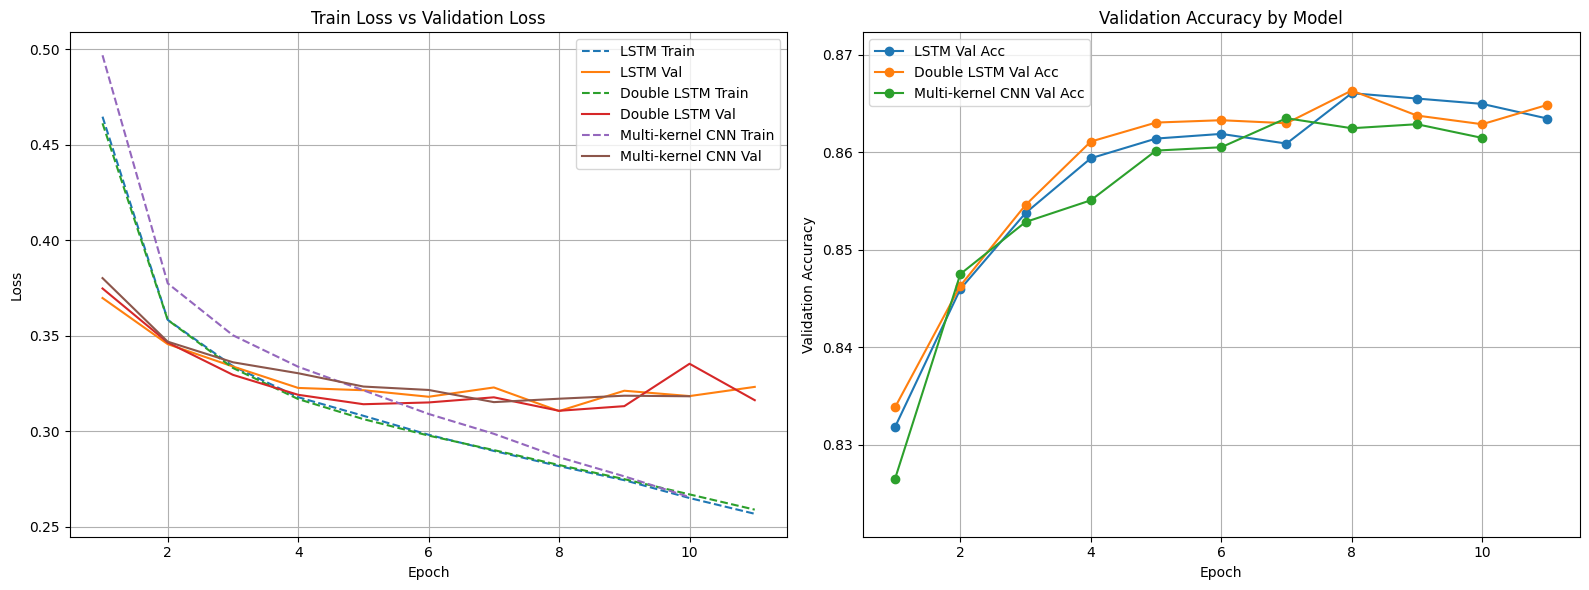

In [21]:
import matplotlib.pyplot as plt
import numpy as np

display_names = {
    "lstm": "LSTM",
    "double_lstm": "Double LSTM",
    "multi_kernel_cnn": "Multi-kernel CNN",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: Train Loss vs Validation Loss
ax = axes[0]

for model_key, history in histories.items():
    model_name = display_names.get(model_key, model_key)

    ax.plot(
        history["epoch"],
        history["train_loss"],
        linestyle="--",
        label=f"{model_name} Train"
    )

    ax.plot(
        history["epoch"],
        history["val_loss"],
        linestyle="-",
        label=f"{model_name} Val"
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Train Loss vs Validation Loss")
ax.grid(True)
ax.legend()

# 오른쪽: Validation Accuracy
ax = axes[1]

all_val_acc = []

for model_key, history in histories.items():
    model_name = display_names.get(model_key, model_key)

    ax.plot(
        history["epoch"],
        history["val_acc"],
        linestyle="-",
        marker="o",
        label=f"{model_name} Val Acc"
    )

    all_val_acc.extend(history["val_acc"].values)

# validation accuracy 범위 자동 확대
all_val_acc = np.array(all_val_acc)
acc_min = all_val_acc.min()
acc_max = all_val_acc.max()
margin = max((acc_max - acc_min) * 0.15, 0.005)

y_min = max(0.0, acc_min - margin)
y_max = min(1.0, acc_max + margin)

ax.set_ylim(y_min, y_max)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy by Model")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

---  
성능 자체는 86.5% +- 1%p 이내로 대부분 고만고만한 차이였다. 기존 노드 학습에서 빠른 과적합 양상이 관찰되어 꽤 강한 dropout=0.5를 적용했음에도 epoch 6 근처에서 train loss/val loss가 갈라서며 과적합이 아직도 빠르게 나타나는 것을 볼 수 있다. 

7) 학습된 Embedding 레이어 분석  

In [22]:
from gensim.models import KeyedVectors

# 세 모델 중 test accuracy가 가장 높았던 Double LSTM의 best checkpoint를 사용
checkpoint_path = "./histories/double_lstm_best.pt"
embedding_file_path = "./histories/double_lstm_embedding.txt"

checkpoint = torch.load(checkpoint_path, map_location=device)
model_double_lstm.load_state_dict(checkpoint)
model_double_lstm.to(device)
model_double_lstm.eval()

embedding_weights = model_double_lstm.embedding.weight.detach().cpu().numpy()
num_embeddings, embedding_dim = embedding_weights.shape

print("checkpoint 로드 완료:", checkpoint_path)
print("Embedding weight shape:", embedding_weights.shape)

# <PAD>, <BOS>, <UNK>, <UNUSED>를 제외하고 word2vec 텍스트 형식으로 저장합니다.
special_token_count = 4
vocab_count = num_embeddings - special_token_count

with open(embedding_file_path, "w", encoding="utf-8") as f:
    f.write(f"{vocab_count} {embedding_dim}\n")

    for index in range(special_token_count, num_embeddings):
        word = index_to_word[index]
        vector = " ".join(map(str, embedding_weights[index]))
        f.write(f"{word} {vector}\n")

print("임베딩 저장 완료:", embedding_file_path)
print(f"저장 단어 수: {vocab_count}, 임베딩 차원: {embedding_dim}")

checkpoint 로드 완료: ./histories/double_lstm_best.pt
Embedding weight shape: (10000, 100)
임베딩 저장 완료: ./histories/double_lstm_embedding.txt
저장 단어 수: 9996, 임베딩 차원: 100


In [23]:
# 직접 학습한 임베딩 파일은 word2vec 텍스트 형식이므로 load_word2vec_format()으로 불러옵니다.
learned_word_vectors = KeyedVectors.load_word2vec_format(
    embedding_file_path,
    binary=False,
    encoding="utf-8"
)

print("gensim vocabulary size:", len(learned_word_vectors))
print("gensim vector size:", learned_word_vectors.vector_size)

query_words = ["영화", "재미", "연기", "최고", "별로"]

for query_word in query_words:
    print(f"\n[{query_word}]와 가까운 단어")

    if query_word not in learned_word_vectors.key_to_index:
        print("  단어가 학습 사전에 없습니다.")
        continue

    for similar_word, similarity in learned_word_vectors.most_similar(
        query_word,
        topn=10
    ):
        print(f"  {similar_word:<12} {similarity:.4f}")

gensim vocabulary size: 9996
gensim vector size: 100

[영화]와 가까운 단어
  라는           0.4654
  쉽            0.3641
  V            0.3551
  버렸           0.3451
  ㅜㅜ           0.3425
  이야기          0.3422
  시리즈          0.3421
  정말           0.3415
  에게           0.3411
  남            0.3234

[재미]와 가까운 단어
  젤            0.5294
  보다           0.3942
  너무나          0.3900
  감흥           0.3867
  41           0.3863
  취향           0.3856
  마법           0.3853
  옛다           0.3851
  공포           0.3835
  한번           0.3793

[연기]와 가까운 단어
  캐릭터          0.4072
  +            0.3933
  셨            0.3738
  남            0.3585
  다행           0.3572
  어서           0.3418
  벽            0.3271
  동생           0.3185
  하느님          0.3160
  성장           0.3125

[최고]와 가까운 단어
  굿            0.7029
  낙            0.7015
  수작           0.6972
  천재           0.6761
  안다           0.6692
  류승완          0.6645
  짱            0.6642
  ♥            0.6627
  정책           0.6626
  이뻐요          0.6567

[별로]와 가까운 

8) 한국어 Word2Vec 임베딩 활용하여 성능 개선  
한국어 Word2Vec은 /data 폴더 안에 있는 word2vec_ko.model을 활용하세요.  
한국어 Word2Vec을 활용할 때는 load_word2vec_format() 형태가 아닌 load() 형태로 모델을 불러와주세요. 또한 모델을 활용할 때에는 아래 예시와 같이 .wv를 붙여서 활용합니다. 

In [24]:
from gensim.models import Word2Vec

word2vec_file_path = os.path.expanduser("~/data/word2vec_ko.model")

# .model 파일은 전체 Word2Vec 모델이므로 load()로 불러오고,
# 실제 단어 벡터에는 .wv를 통해 접근합니다.
word2vec_model = Word2Vec.load(word2vec_file_path)
word2vec_vectors = word2vec_model.wv

print("Word2Vec vocabulary size:", len(word2vec_vectors))
print("Word2Vec vector size:", word2vec_vectors.vector_size)

query_words = ["영화", "재미", "연기", "최고", "별로"]

for query_word in query_words:
    print(f"\n[{query_word}]와 가까운 사전학습 단어")

    if query_word not in word2vec_vectors.key_to_index:
        print("  단어가 Word2Vec 사전에 없습니다.")
        continue

    for similar_word, similarity in word2vec_vectors.most_similar(
        query_word,
        topn=10
    ):
        print(f"  {similar_word:<12} {similarity:.4f}")

Word2Vec vocabulary size: 302960
Word2Vec vector size: 100

[영화]와 가까운 사전학습 단어
  드라마          0.8419
  뮤지컬          0.7775
  코미디          0.7489
  다큐멘터리        0.7401
  헐리우드         0.7398
  애니메이션        0.7171
  독립영화         0.7114
  로맨틱          0.7108
  장편           0.7102
  극영화          0.7045

[재미]와 가까운 사전학습 단어
  묘미           0.6163
  취미           0.6035
  흥미           0.5940
  유머           0.5889
  보람           0.5690
  즐거움          0.5631
  개그           0.5553
  이야기          0.5537
  연애           0.5523
  열의           0.5465

[연기]와 가까운 사전학습 단어
  연출           0.7650
  열연           0.6947
  캐스팅          0.6806
  촬영           0.6222
  데이트          0.6133
  섭외           0.6094
  각색           0.6067
  분장           0.5992
  립싱크          0.5987
  출연           0.5949

[최고]와 가까운 사전학습 단어
  역대           0.6544
  최다           0.6140
  최악           0.6104
  최대           0.6002
  최저           0.5937
  정상급          0.5869
  올해           0.5791
  우수           0.5667
  최고령          0.5548
  최초   

In [30]:
from IPython.display import display, Markdown

# 같은 기준 단어에 대해 직접 학습한 임베딩과 사전학습 Word2Vec을 나란히 비교합니다.
def get_similar_words_for_comparison(vectors, query_word, topn=10):
    if query_word not in vectors.key_to_index:
        return [("사전에 없음", np.nan)] * topn

    similar_words = vectors.most_similar(query_word, topn=topn)
    return [
        (word, round(float(similarity), 4))
        for word, similarity in similar_words
    ]


embedding_comparison_tables = {}

for query_word in query_words:
    learned_results = get_similar_words_for_comparison(
        learned_word_vectors,
        query_word,
        topn=10
    )
    pretrained_results = get_similar_words_for_comparison(
        word2vec_vectors,
        query_word,
        topn=10
    )

    comparison_df = pd.DataFrame({
        "직접 학습 단어": [word for word, _ in learned_results],
        "직접 학습 유사도": [similarity for _, similarity in learned_results],
        "사전학습 단어": [word for word, _ in pretrained_results],
        "사전학습 유사도": [similarity for _, similarity in pretrained_results],
    })

    embedding_comparison_tables[query_word] = comparison_df

    display(Markdown(f"### 기준 단어: `{query_word}`"))
    display(
        comparison_df.style.format({
            "직접 학습 유사도": "{:.4f}",
            "사전학습 유사도": "{:.4f}",
        }, na_rep="-")
    )

### 기준 단어: `영화`

,직접 학습 단어,직접 학습 유사도,사전학습 단어,사전학습 유사도
0,라는,0.4654,드라마,0.8419
1,쉽,0.3641,뮤지컬,0.7775
2,V,0.3551,코미디,0.7489
3,버렸,0.3451,다큐멘터리,0.7401
4,ㅜㅜ,0.3425,헐리우드,0.7398
5,이야기,0.3422,애니메이션,0.7171
6,시리즈,0.3421,독립영화,0.7114
7,정말,0.3415,로맨틱,0.7108
8,에게,0.3411,장편,0.7102
9,남,0.3234,극영화,0.7045


### 기준 단어: `재미`

,직접 학습 단어,직접 학습 유사도,사전학습 단어,사전학습 유사도
0,젤,0.5294,묘미,0.6163
1,보다,0.3942,취미,0.6035
2,너무나,0.3900,흥미,0.5940
3,감흥,0.3867,유머,0.5889
4,41,0.3863,보람,0.5690
5,취향,0.3856,즐거움,0.5631
6,마법,0.3853,개그,0.5553
7,옛다,0.3851,이야기,0.5537
8,공포,0.3835,연애,0.5523
9,한번,0.3793,열의,0.5465


### 기준 단어: `연기`

,직접 학습 단어,직접 학습 유사도,사전학습 단어,사전학습 유사도
0,캐릭터,0.4072,연출,0.7650
1,+,0.3933,열연,0.6947
2,셨,0.3738,캐스팅,0.6806
3,남,0.3585,촬영,0.6222
4,다행,0.3572,데이트,0.6133
5,어서,0.3418,섭외,0.6094
6,벽,0.3271,각색,0.6067
7,동생,0.3185,분장,0.5992
8,하느님,0.3160,립싱크,0.5987
9,성장,0.3125,출연,0.5949


### 기준 단어: `최고`

,직접 학습 단어,직접 학습 유사도,사전학습 단어,사전학습 유사도
0,굿,0.7029,역대,0.6544
1,낙,0.7015,최다,0.6140
2,수작,0.6972,최악,0.6104
3,천재,0.6761,최대,0.6002
4,안다,0.6692,최저,0.5937
5,류승완,0.6645,정상급,0.5869
6,짱,0.6642,올해,0.5791
7,♥,0.6627,우수,0.5667
8,정책,0.6626,최고령,0.5548
9,이뻐요,0.6567,최초,0.5518


### 기준 단어: `별로`

,직접 학습 단어,직접 학습 유사도,사전학습 단어,사전학습 유사도
0,픽,0.8860,전혀,0.6422
1,지못미,0.8831,그다지,0.6234
2,껐,0.8801,꽤,0.6036
3,쯧,0.8788,확실히,0.5738
4,느리,0.8784,딱히,0.5515
5,지겨움,0.8783,상당히,0.5422
6,구림,0.8763,볼일,0.5412
7,이뭐병,0.8748,다름,0.5314
8,꺼버렸,0.8746,별,0.5229
9,정체불명,0.8743,확연히,0.5194


---  
얼핏 보면 사전학습 임베딩이 훨씬 더 상식적인 유사 단어를 내놓는 것 같지만, 아래에서 확인했듯 큰 성능 개선을 보여주진 않았는데, '별로' 와 같은 긍정/부정의 의미를 포함한 단어에서는 그래도 납득할만한 임베딩이 애초에 형성되어 있었기 때문으로 보인다. 꼭 거대한 데이터가 정답만은 아닐수도 있다는 것을 확인하였다. 

In [26]:
# NSMC 사전에서 Word2Vec 벡터를 사용할 수 있는 단어의 비율을 확인합니다.
vocab_indices = range(4, vocab_size)
covered_indices = [
    index
    for index in vocab_indices
    if index_to_word[index] in word2vec_vectors.key_to_index
]

token_frequency = Counter(
    index
    for sentence in X_train
    for index in sentence
    if index >= 4
)
total_token_count = sum(token_frequency.values())
covered_token_count = sum(token_frequency[index] for index in covered_indices)

vocab_coverage = len(covered_indices) / (vocab_size - 4)
token_coverage = covered_token_count / total_token_count

print(
    f"어휘 포함률: {len(covered_indices):,}/{vocab_size - 4:,} "
    f"({vocab_coverage * 100:.2f}%)"
)
print(
    f"등장 빈도 기준 포함률: {covered_token_count:,}/{total_token_count:,} "
    f"({token_coverage * 100:.2f}%)"
)

if word2vec_vectors.vector_size != word_vector_dim:
    raise ValueError(
        f"Word2Vec 차원({word2vec_vectors.vector_size})과 "
        f"모델 임베딩 차원({word_vector_dim})이 다릅니다."
    )

# OOV 단어와 특수 토큰은 작은 난수로 초기화하고, 포함된 단어는 Word2Vec 벡터로 교체합니다.
embedding_rng = np.random.default_rng(seed)
word2vec_embedding_matrix = embedding_rng.normal(
    loc=0.0,
    scale=0.05,
    size=(vocab_size, word_vector_dim)
).astype(np.float32)

word2vec_embedding_matrix[padding_idx] = 0.0

for index in covered_indices:
    word2vec_embedding_matrix[index] = word2vec_vectors[index_to_word[index]]

print("Word2Vec embedding matrix shape:", word2vec_embedding_matrix.shape)
print("PAD vector norm:", np.linalg.norm(word2vec_embedding_matrix[padding_idx]))

어휘 포함률: 9,458/9,996 (94.62%)
등장 빈도 기준 포함률: 2,225,586/2,248,931 (98.96%)
Word2Vec embedding matrix shape: (10000, 100)
PAD vector norm: 0.0


In [27]:
def initialize_embedding_with_word2vec(model, embedding_matrix):
    embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

    if model.embedding.weight.shape != embedding_tensor.shape:
        raise ValueError(
            f"모델 임베딩 shape {tuple(model.embedding.weight.shape)}와 "
            f"초기화 행렬 shape {tuple(embedding_tensor.shape)}가 다릅니다."
        )

    with torch.no_grad():
        model.embedding.weight.copy_(embedding_tensor)

    # 사전학습 벡터를 고정하지 않고 NSMC 감성 분류 목적에 맞게 미세조정합니다.
    model.embedding.weight.requires_grad = True
    return model


torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

model_word2vec_lstm = LSTMSentimentModel(
    vocab_size=vocab_size,
    word_vector_dim=word_vector_dim,
    hidden_size=hidden_size,
    padding_idx=padding_idx,
    dropout=dropout_rate
)

model_word2vec_double_lstm = DoubleLayerLSTMSentimentModel(
    vocab_size=vocab_size,
    word_vector_dim=word_vector_dim,
    hidden_size=hidden_size,
    padding_idx=padding_idx,
    dropout=dropout_rate
)

model_word2vec_cnn = MultiKernelCNNSentimentModel(
    vocab_size=vocab_size,
    word_vector_dim=word_vector_dim,
    num_filters=64,
    padding_idx=padding_idx,
    dropout=dropout_rate
)

word2vec_models = {
    "word2vec_lstm": model_word2vec_lstm,
    "word2vec_double_lstm": model_word2vec_double_lstm,
    "word2vec_multi_kernel_cnn": model_word2vec_cnn,
}

for model_name, model in word2vec_models.items():
    initialize_embedding_with_word2vec(model, word2vec_embedding_matrix)
    model.to(device)
    print(
        f"{model_name}: embedding={tuple(model.embedding.weight.shape)}, "
        f"trainable={model.embedding.weight.requires_grad}"
    )

word2vec_lstm: embedding=(10000, 100), trainable=True
word2vec_double_lstm: embedding=(10000, 100), trainable=True
word2vec_multi_kernel_cnn: embedding=(10000, 100), trainable=True


In [28]:
# 이 셀을 실행하면 Word2Vec으로 초기화한 세 모델을 순차적으로 학습합니다.
# 기존 baseline 파일과 구분되는 이름을 사용하므로 이전 결과를 덮어쓰지 않습니다.
hist_word2vec_lstm, test_loss_word2vec_lstm, test_acc_word2vec_lstm = fit_or_load_history(
    model=model_word2vec_lstm,
    model_name="word2vec_lstm",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay,
    patience=patience,
    history_dir="./histories",
    force_train=False
)

hist_word2vec_double_lstm, test_loss_word2vec_double_lstm, test_acc_word2vec_double_lstm = fit_or_load_history(
    model=model_word2vec_double_lstm,
    model_name="word2vec_double_lstm",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay,
    patience=patience,
    history_dir="./histories",
    force_train=False
)

hist_word2vec_cnn, test_loss_word2vec_cnn, test_acc_word2vec_cnn = fit_or_load_history(
    model=model_word2vec_cnn,
    model_name="word2vec_multi_kernel_cnn",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay,
    patience=patience,
    history_dir="./histories",
    force_train=False
)

[SKIP] word2vec_lstm: 기존 history 파일 발견
       ./histories/history_word2vec_lstm.csv
       best checkpoint 로드 완료: ./histories/word2vec_lstm_best.pt
[word2vec_lstm] Test Loss: 0.3074 | Test Acc: 0.8668
[SKIP] word2vec_double_lstm: 기존 history 파일 발견
       ./histories/history_word2vec_double_lstm.csv
       best checkpoint 로드 완료: ./histories/word2vec_double_lstm_best.pt
[word2vec_double_lstm] Test Loss: 0.3080 | Test Acc: 0.8672
[SKIP] word2vec_multi_kernel_cnn: 기존 history 파일 발견
       ./histories/history_word2vec_multi_kernel_cnn.csv
       best checkpoint 로드 완료: ./histories/word2vec_multi_kernel_cnn_best.pt
[word2vec_multi_kernel_cnn] Test Loss: 0.3171 | Test Acc: 0.8636


,model,embedding,best_val_acc,test_acc
0,LSTM,From Scratch,0.866056,0.863010
1,LSTM,Word2Vec,0.868039,0.866774
2,Double LSTM,From Scratch,0.866329,0.865675
3,Double LSTM,Word2Vec,0.867971,0.867160
4,Multi-kernel CNN,From Scratch,0.863490,0.863417
5,Multi-kernel CNN,Word2Vec,0.864003,0.863621


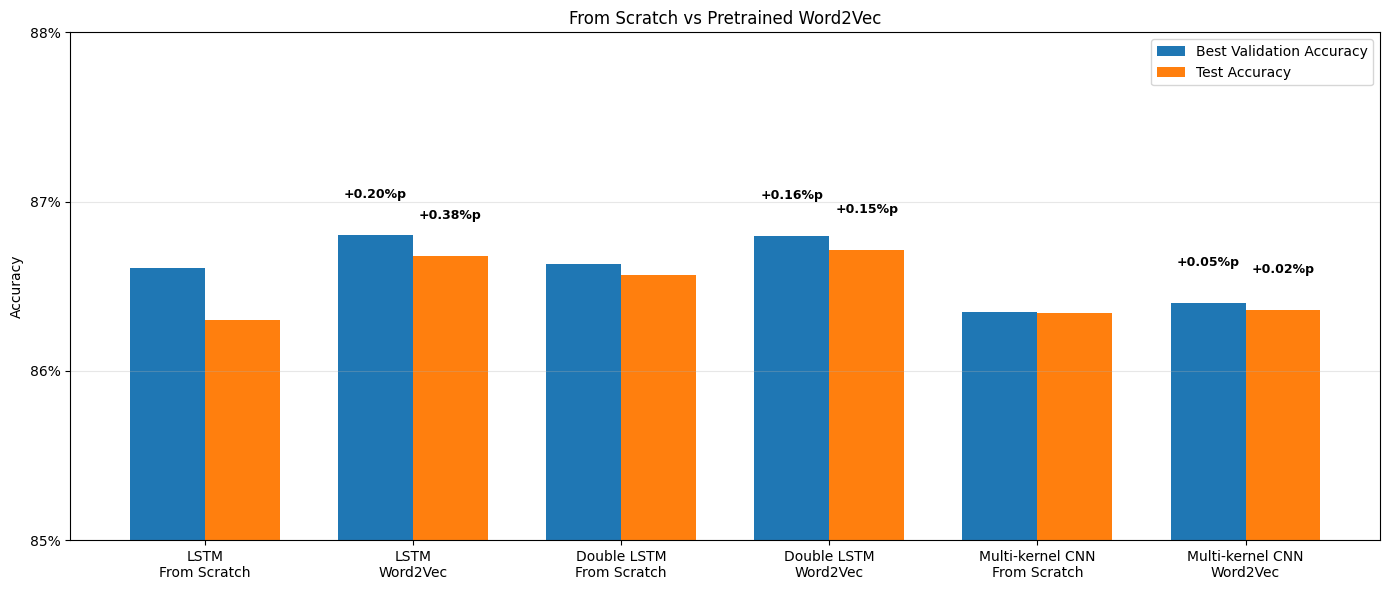

In [29]:
# baseline과 Word2Vec 초기화 모델의 최고 validation accuracy와 test accuracy를 비교합니다.
comparison_rows = [
    {
        "model": "LSTM",
        "embedding": "From Scratch",
        "best_val_acc": hist_lstm["val_acc"].max(),
        "test_acc": test_acc_lstm,
    },
    {
        "model": "LSTM",
        "embedding": "Word2Vec",
        "best_val_acc": hist_word2vec_lstm["val_acc"].max(),
        "test_acc": test_acc_word2vec_lstm,
    },
    {
        "model": "Double LSTM",
        "embedding": "From Scratch",
        "best_val_acc": hist_double_lstm["val_acc"].max(),
        "test_acc": test_acc_double_lstm,
    },
    {
        "model": "Double LSTM",
        "embedding": "Word2Vec",
        "best_val_acc": hist_word2vec_double_lstm["val_acc"].max(),
        "test_acc": test_acc_word2vec_double_lstm,
    },
    {
        "model": "Multi-kernel CNN",
        "embedding": "From Scratch",
        "best_val_acc": hist_cnn["val_acc"].max(),
        "test_acc": test_acc_cnn,
    },
    {
        "model": "Multi-kernel CNN",
        "embedding": "Word2Vec",
        "best_val_acc": hist_word2vec_cnn["val_acc"].max(),
        "test_acc": test_acc_word2vec_cnn,
    },
]

word2vec_comparison = pd.DataFrame(comparison_rows)
word2vec_comparison["label"] = (
    word2vec_comparison["model"] + "\n" + word2vec_comparison["embedding"]
)

# 각 Word2Vec 모델의 바로 앞 행은 같은 구조의 From Scratch 모델입니다.
word2vec_indices = word2vec_comparison.index[
    word2vec_comparison["embedding"] == "Word2Vec"
]
val_improvement = {}
test_improvement = {}

for word2vec_index in word2vec_indices:
    scratch_index = word2vec_index - 1
    val_improvement[word2vec_index] = (
        word2vec_comparison.loc[word2vec_index, "best_val_acc"]
        - word2vec_comparison.loc[scratch_index, "best_val_acc"]
    )
    test_improvement[word2vec_index] = (
        word2vec_comparison.loc[word2vec_index, "test_acc"]
        - word2vec_comparison.loc[scratch_index, "test_acc"]
    )
word2vec_comparison.to_csv(
    "./histories/word2vec_model_comparison.csv",
    index=False
)

display(word2vec_comparison.drop(columns="label"))

x = np.arange(len(word2vec_comparison))
width = 0.36

fig, ax = plt.subplots(figsize=(14, 6))
val_bars = ax.bar(
    x - width / 2,
    word2vec_comparison["best_val_acc"],
    width,
    label="Best Validation Accuracy"
)
test_bars = ax.bar(
    x + width / 2,
    word2vec_comparison["test_acc"],
    width,
    label="Test Accuracy"
)

score_columns = word2vec_comparison[["best_val_acc", "test_acc"]]
score_min = score_columns.min().min()
score_max = score_columns.max().max()

# 정확도 차이와 개선폭 라벨이 모두 잘 보이도록 y축 범위를 자동 설정합니다.
y_min = max(0.0, np.floor((score_min - 0.01) * 100) / 100)
annotation_offset = max((score_max - score_min) * 0.04, 0.002)
annotation_top = score_max + annotation_offset + 0.008
y_max = min(1.0, np.ceil(annotation_top * 100) / 100)
y_ticks = np.arange(y_min, y_max + 0.001, 0.01)

ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{tick * 100:.0f}%" for tick in y_ticks])

# Word2Vec 막대에만 같은 모델의 From Scratch 대비 변화량을 %p로 표시합니다.
for word2vec_index in word2vec_indices:
    val_bar = val_bars[word2vec_index]
    test_bar = test_bars[word2vec_index]

    ax.text(
        val_bar.get_x() + val_bar.get_width() / 2,
        val_bar.get_height() + annotation_offset,
        f"{val_improvement[word2vec_index] * 100:+.2f}%p",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )
    ax.text(
        test_bar.get_x() + test_bar.get_width() / 2,
        test_bar.get_height() + annotation_offset,
        f"{test_improvement[word2vec_index] * 100:+.2f}%p",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )
ax.set_xticks(x)
ax.set_xticklabels(word2vec_comparison["label"])
ax.set_ylabel("Accuracy")
ax.set_title("From Scratch vs Pretrained Word2Vec")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### 결과 및 회고 

직접 학습한 임베딩과 사전학습 Word2Vec 임베딩을 각각 LSTM, Double LSTM, Multi-kernel CNN 모델에 적용하여 성능을 비교하였다. 실험 결과, 세 모델 모두 사전학습 Word2Vec을 사용했을 때 검증 정확도와 테스트 정확도가 소폭 향상되었다. LSTM은 검증 정확도 기준 약 +0.20%p, 테스트 정확도 기준 약 +0.38%p 향상되었고, Double LSTM은 각각 +0.16%p, +0.15%p 향상되었다. Multi-kernel CNN 역시 향상은 있었지만 검증 정확도 +0.05%p, 테스트 정확도 +0.02%p 수준으로 매우 제한적이었다. 전체적으로 사전학습 임베딩이 성능 개선에 긍정적인 영향을 주기는 했지만, 모든 모델이 이미 85~87%대 정확도에 도달한 상태였기 때문에 개선 폭은 0.5%p 미만으로 작게 나타났다.

임베딩 자체를 비교했을 때는 사전학습 Word2Vec이 훨씬 안정적인 의미 관계를 보였다. 예를 들어 사전학습 임베딩에서는 영화 주변에 드라마, 뮤지컬, 코미디, 다큐멘터리 등이 나타났고, 연기 주변에도 연출, 열연, 캐스팅, 촬영처럼 의미적으로 관련된 단어들이 배치되었다.  
반면 직접 학습한 임베딩에서는 영화 주변에 라는, 쉽, V, ㅜㅜ 같은 비교적 불안정한 단어들이 함께 나타나 일반적인 의미 표현 품질은 낮아 보였다. 그러나 감성분석의 목적은 모든 단어의 일반적 의미 관계를 정교하게 표현하는 것이 아닌 긍정과 부정을 구분하는 데 필요한 신호를 학습하는 것이고, 실제로 직접 학습한 임베딩에서도 '최고' 주변에는 '굿, 수작, 짱'과 같은 긍정 표현이, '별로' 주변에는 '지못미, 껐, 쯧, 지겨움, 구림, 이뭐병'과 같은 부정 표현이 비교적 일관되게 모였기 때문에 직접 학습한 임베딩에서도 좋은 성능을 보였다고 볼 수 있으며 사전 학습 임베딩의 낮은 개선폭도 설명이 될 것이다. 

따라서 이번 결과는 사전학습 임베딩이 단어의 일반적인 의미 관계를 더 잘 반영하더라도, 이것이 감성분류 정확도의 큰 향상으로 바로 이어지지는 않는다는 점을 보여준다. 특히 직접 학습한 임베딩은 중립적 단어나 도메인 일반 단어에 대해서는 불안정했지만, 긍정/부정 분류에 직접적으로 기여하는 감성 단어에 대해서는 나름 합리적인 표현을 학습한 것으로 보인다. 이 때문에 사전학습 임베딩을 적용했을 때 성능이 개선되기는 했지만, 개선 폭은 제한적으로 나타났다고 해석할 수 있다. 또한 사전학습 임베딩은 더 넓은 말뭉치에서 학습되었기 때문에 일반 의미 표현에는 강점이 있지만, 영화 리뷰 데이터 특유의 짧은 표현, 비속어, 이모티콘, 반어적 표현, 도메인 특화 감성 표현을 반드시 더 잘 반영한다고 보기는 어렵다.

정말 난해하다... 뭔가를 만들긴 했는데 그 이면에서 대체 뭐가 돌아가고 있는건지 모르겠다. 